# Customer Churn Analysis

This project analyzes customer churn behavior using Python.

Tools:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn


In [16]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Load Dataset

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn (1).csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning

In [18]:
# Check dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [19]:
# Convert TotalCharges column to numeric

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"], 
    errors="coerce"
)

# Remove missing values

df = df.dropna()

df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

## Exploratory Data Analysis (EDA)

In [20]:
# Churn distribution

df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [21]:
# Churn percentage

df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

## Data Visualization

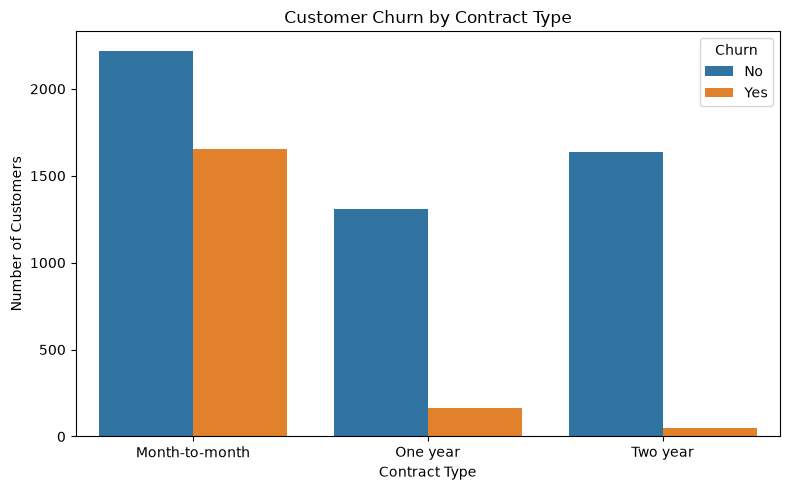

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig("images/contract_churn.png", dpi=300, bbox_inches="tight")

plt.show()

plt.close()

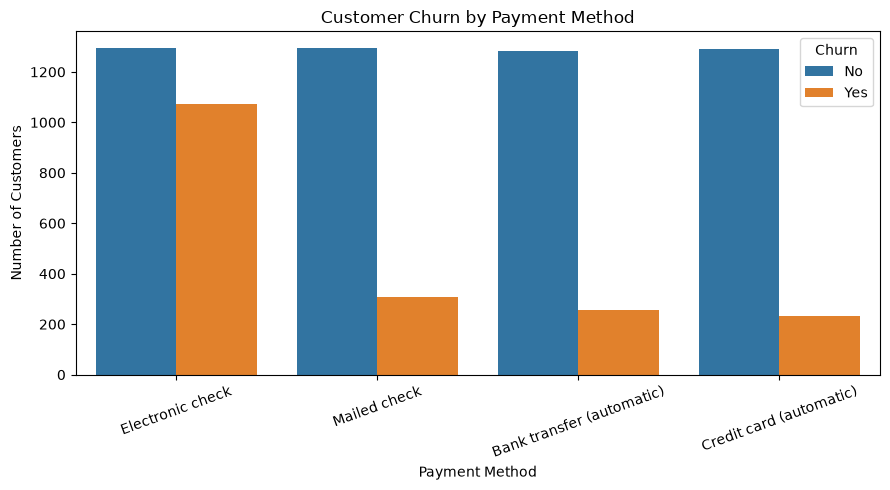

In [23]:
plt.figure(figsize=(9,5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig("images/payment_method_churn.png", dpi=300, bbox_inches="tight")

plt.show()

plt.close()

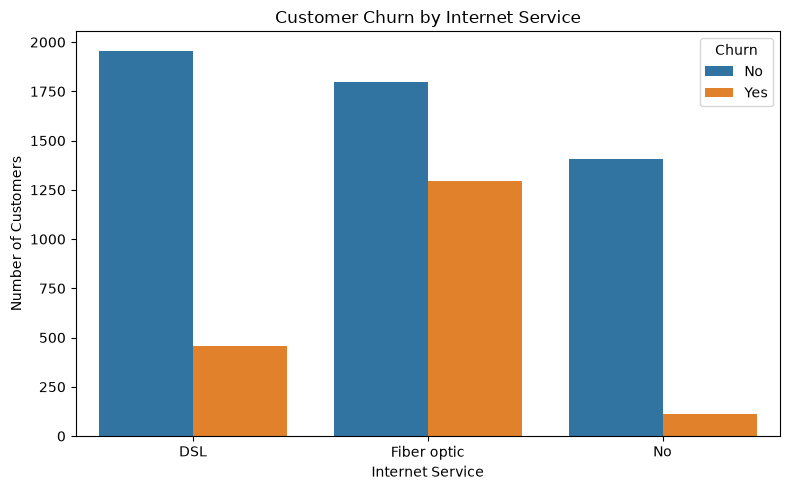

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig("images/internet_service_churn.png", dpi=300, bbox_inches="tight")

plt.show()

plt.close()

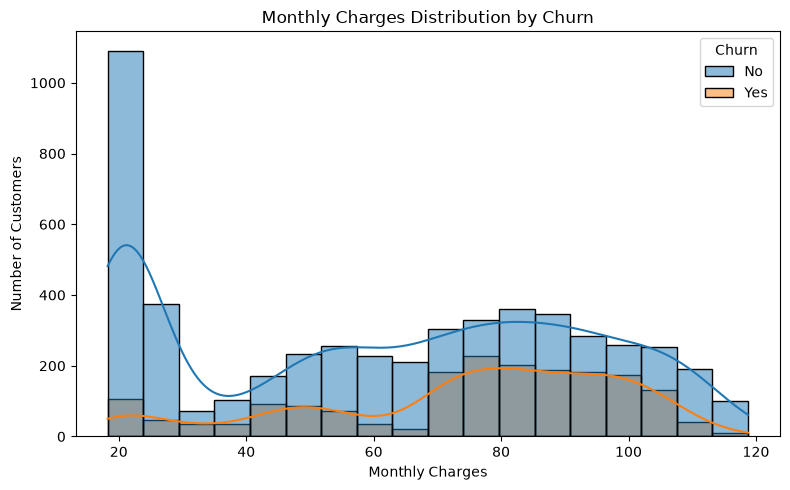

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df, 
    x="MonthlyCharges", 
    hue="Churn", 
    kde=True
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig("images/monthly_charges_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

plt.close()

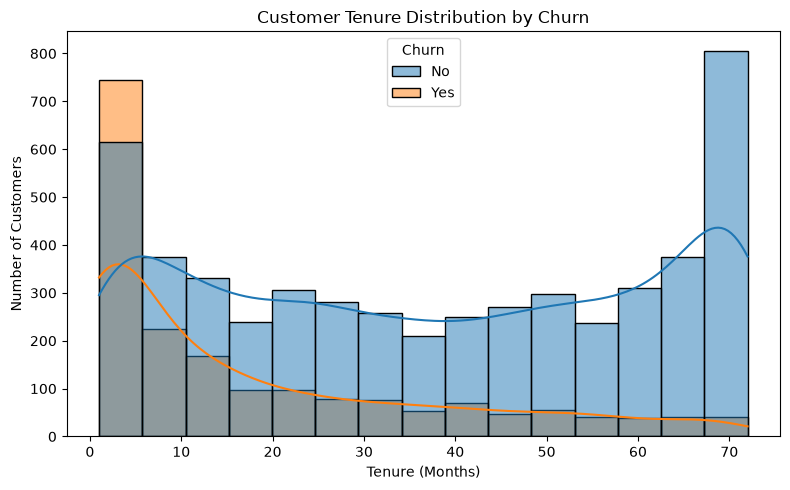

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df, 
    x="tenure", 
    hue="Churn", 
    kde=True
)

plt.title("Customer Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig("images/tenure_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

plt.close()

## Business Insights

### Key Findings

- Month-to-month contract customers have the highest churn rate.
- Customers using Electronic Check payment method show higher churn.
- Fiber optic customers have higher churn compared to DSL customers.
- New customers with low tenure are more likely to leave.
- Overall churn rate is approximately 26.58%.

## Conclusion

This project analyzed customer churn patterns using Python.

The analysis included data cleaning, exploratory data analysis (EDA), and data visualization.

Key factors affecting customer churn were identified, including contract type, payment method, internet service, monthly charges, and customer tenure.

These insights can help businesses understand customer behavior and develop better retention strategies.